In [34]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout, Input

train_df = pd.read_csv("Downloads/archive/Train.csv")
IMG_SIZE = 32

def load_images(df, base_path=""):
    images, labels = [], []
    for _, row in df.iterrows():
        img_path = base_path + row["Path"]
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: could not read {img_path}")
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
        images.append(img)
        labels.append(row["ClassId"])
    return np.array(images), np.array(labels)

In [19]:
X,y= load_images(train_df, base_path="Downloads/archive/")
X_train,X_cval,y_train,y_cval=train_test_split(X,y,test_size=0.2,random_state=42)
nclass = 43
y_train= to_categorical(y_train,nclass)
y_cval=to_categorical(y_cval,nclass)

In [21]:
model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(nclass, activation='softmax')
])

In [22]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    X_train, y_train,
    validation_data=(X_cval, y_cval),
    epochs=20,
    batch_size=64
)

Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.6510 - loss: 1.2165 - val_accuracy: 0.8472 - val_loss: 0.5176
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9336 - loss: 0.2059 - val_accuracy: 0.9681 - val_loss: 0.1039
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9696 - loss: 0.0985 - val_accuracy: 0.9857 - val_loss: 0.0495
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.9775 - loss: 0.0690 - val_accuracy: 0.9783 - val_loss: 0.0715
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.9817 - loss: 0.0547 - val_accuracy: 0.9852 - val_loss: 0.0501
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9828 - loss: 0.0519 - val_accuracy: 0.9879 - val_loss: 0.0400
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9853 - loss: 0.0461 - val_accuracy: 0.9925 - val_loss: 0.0270
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9860 - loss: 0.0448 - 

In [23]:
test_df = pd.read_csv("Downloads/archive/Test.csv")
X_test, y_test = load_images(test_df, base_path="Downloads/archive/")
y_test_cat=to_categorical(y_test,nclass)
loss, acc = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {acc:.4f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9481 - loss: 0.3214
Test Accuracy: 0.9481


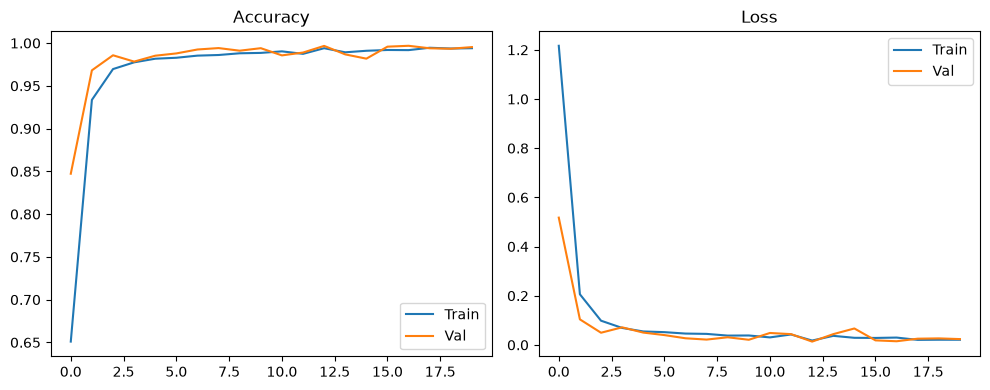

In [24]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Predicted: Turn right ahead
Confidence: 100.0%
Class ID: 33


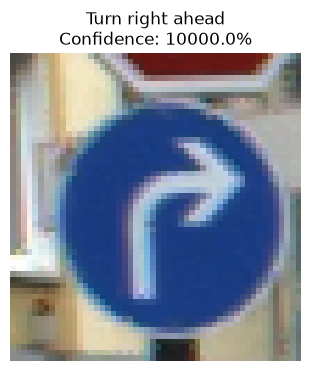

In [33]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model

CLASS_NAMES = {
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)',
    9: 'No passing', 10: 'No passing (vehicles > 3.5t)', 11: 'Right-of-way at intersection',
    12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles',
    16: 'Vehicles > 3.5t prohibited', 17: 'No entry', 18: 'General caution',
    19: 'Dangerous curve left', 20: 'Dangerous curve right', 21: 'Double curve',
    22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows on the right',
    25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing',
    29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing',
    32: 'End speed + passing limits', 33: 'Turn right ahead', 34: 'Turn left ahead',
    35: 'Ahead only', 36: 'Go straight or right', 37: 'Go straight or left',
    38: 'Keep right', 39: 'Keep left', 40: 'Roundabout mandatory',
    41: 'End of no passing', 42: 'End no passing (vehicles > 3.5t)'
}
import matplotlib.pyplot as plt

def predict_sign(image_path, model):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    
    img = cv2.resize(img, (32, 32)) / 255.0
    img = np.expand_dims(img, axis=0)  
    
    predictions = model.predict(img)
    class_id = np.argmax(predictions[0])
    confidence = predictions[0][class_id] * 100
    
    print(f"Predicted: {CLASS_NAMES[class_id]}")
    print(f"Confidence: {confidence:.1f}%")
    print(f"Class ID: {class_id}")
    return class_id, confidence
    
def predict_and_show(image_path, model):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Error: Could not read image at '{image_path}'")
        print("Check that the path is correct and the file exists.")
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    class_id, confidence = predict_sign(image_path, model)

    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f"{CLASS_NAMES[class_id]}\nConfidence: {confidence:.1%}")
    plt.axis('off')
    plt.show()

# Usage
predict_and_show("Downloads/archive/Test/00021.png", model)
